In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns

### Reading and Cleaning data

In [2]:
#READING DATA
beijing_df = pd.read_csv('Cities/Beijing_labeled.csv') # loaded correctly with same shape as excel 
chengdu_df = pd.read_csv('Cities/Chengdu_labeled.csv') # assume the below also loaded correctly
guangzhou_df = pd.read_csv('Cities/Guangzhou_labeled.csv')
shanghai_df = pd.read_csv('Cities/Shanghai_labeled.csv')
shenyang_df = pd.read_csv('Cities/Shenyang_labeled.csv')

In [3]:
#RENAMING COLUMNS
rename_dict = {
    'season': 'Season',
    'DEWP': 'Dew_Point', 
    'HUMI': 'Humidity',
    'PRES': 'Pressure', 
    'TEMP': 'Temperature', 
    'Iws': 'Wind_Speed',
    'precipitation': 'Precipitation',
    'cbwd_NE': 'Wind_Dir_NE', 
    'cbwd_NW': 'Wind_Dir_NW', 
    'cbwd_SE': 'Wind_Dir_SE'
}

dfs = [beijing_df, chengdu_df, guangzhou_df, shanghai_df, shenyang_df]

for df in dfs:
    df.rename(columns=rename_dict, inplace=True)

beijing_df.head()

,Season,Dew_Point,Humidity,Pressure,Temperature,Wind_Speed,Precipitation,Wind_Dir_NE,Wind_Dir_NW,Wind_Dir_SE,PM_HIGH
0,4,-8.0,79.0,1026.0,-5.0,23.69,0.0,0,0,1,1.0
1,4,-11.0,85.0,1021.0,-9.0,105.93,1.1,0,0,1,0.0
2,4,-21.0,43.0,1030.0,-11.0,117.55,0.0,0,1,0,0.0
3,4,-25.0,33.0,1034.0,-12.0,39.35,0.0,1,0,0,0.0
4,4,-24.0,30.0,1034.0,-10.0,59.00,0.0,1,0,0,0.0


In [4]:
#ADDING CITY COLUMN AND MERGING DATAFRAMES 
beijing_df['City'] = 'Beijing'
chengdu_df['City'] = 'Chengdu'
guangzhou_df['City'] = 'Guangzhou'
shanghai_df['City'] = 'Shanghai'
shenyang_df['City'] = 'Shenyang'

all_df = pd.concat([beijing_df, chengdu_df, guangzhou_df, 
                           shanghai_df, shenyang_df], 
                          ignore_index=True)


### Exploratory Data Analysis

In [5]:
stats = all_df.describe()
# print(stats)

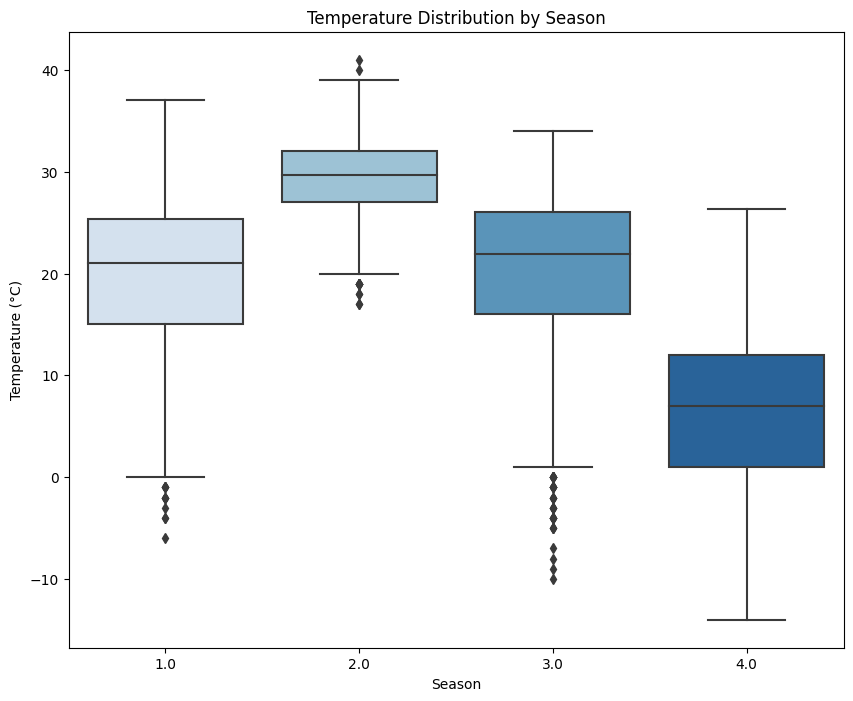

In [6]:
plt.figure(figsize=(10, 8))
blue = sns.color_palette("Blues", n_colors=4)
sns.boxplot(x='Season', y='Temperature', data=all_df, palette=blue)
plt.title('Temperature Distribution by Season')
plt.xlabel('Season')
plt.ylabel('Temperature (°C)')

plt.show()

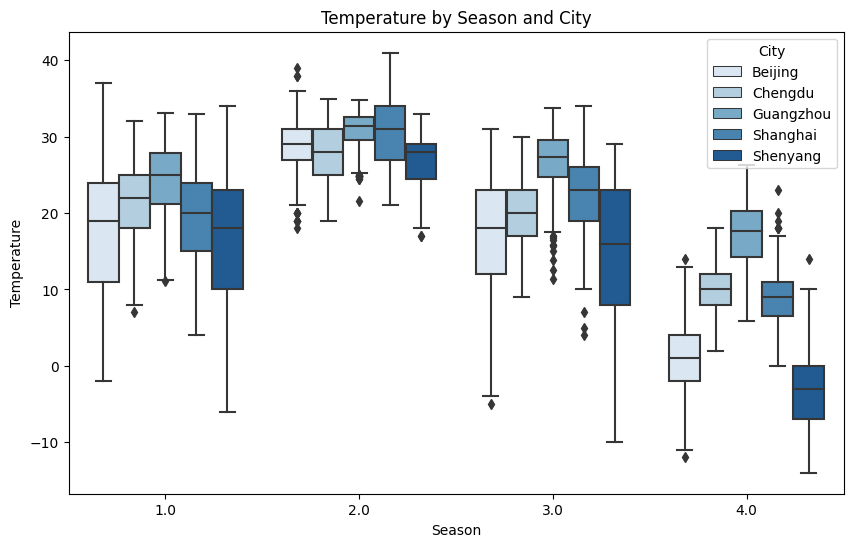

In [7]:
blue_shades = sns.color_palette("Blues", n_colors=5)

plt.figure(figsize=(10, 6))
sns.boxplot(x='Season', y='Temperature', hue='City', data=all_df, palette=blue_shades)
plt.title('Temperature by Season and City')
plt.show()

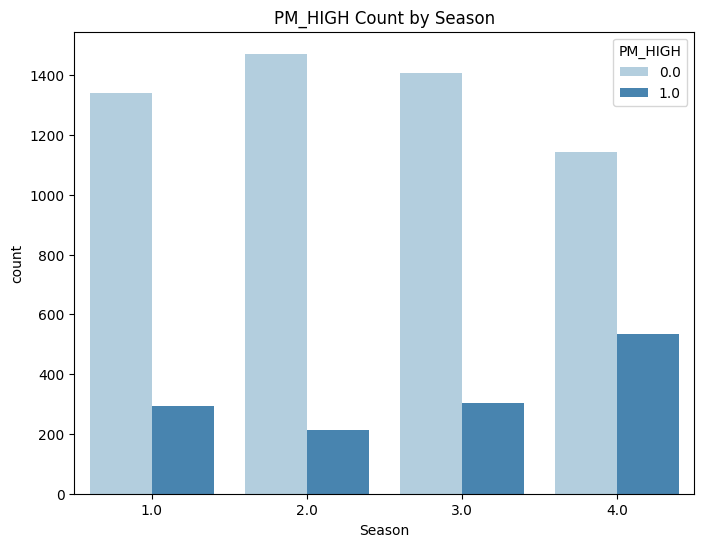

In [8]:
plt.figure(figsize=(8,6))
sns.countplot(x='Season', hue='PM_HIGH', data=all_df, palette='Blues')
plt.title('PM_HIGH Count by Season')
plt.show()

Sparsity: 0.800


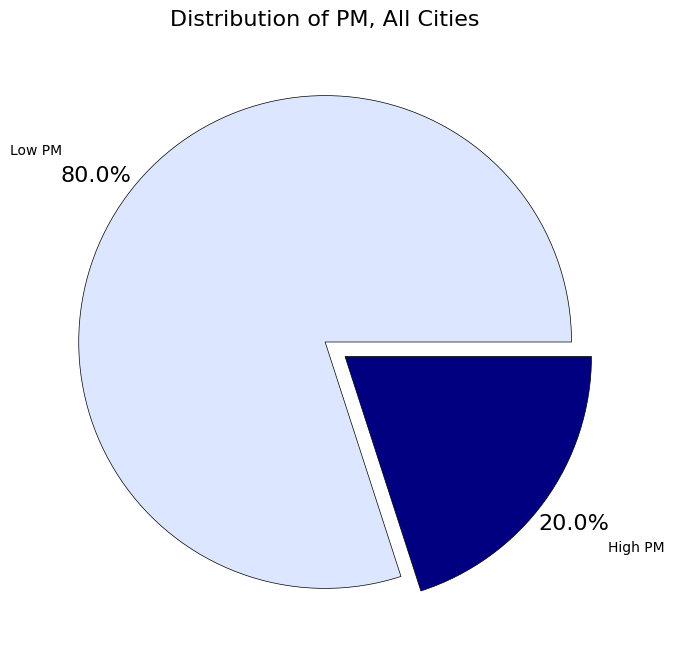

In [9]:
distribution = all_df['PM_HIGH'].value_counts()

# Calculate sparsity
total_elements = sum(distribution)
high_pm = distribution[0]
sparsity = high_pm / total_elements
print(f"Sparsity: {sparsity:.3f}")

# Plot
labels = ['Low PM', 'High PM']
sizes = [high_pm, total_elements - high_pm]

plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=0,
    colors=['#dce7ff', '#000080'],
    wedgeprops={'edgecolor': 'black', 'linewidth': 0.5},
    explode=[0, 0.1],        # Slightly pull out the small slice
    pctdistance=1.15,         # Move percentage text away from center
    labeldistance=1.32        # Move labels further out
)

for autotext in autotexts:
    autotext.set_fontsize(16)

plt.title('Distribution of PM, All Cities', fontsize=16)
plt.show()

In [10]:
distribution_beijing = beijing_df['PM_HIGH'].value_counts()
total_elements_beijing = sum(distribution_beijing)
high_pm_beijing = distribution_beijing[0]
lowpm_beijing = high_pm_beijing / total_elements_beijing
print(f"Low PM Beijing: {lowpm_beijing:.3f}")

distribution_chengdu = chengdu_df['PM_HIGH'].value_counts()
total_elements_chengdu = sum(distribution_chengdu)
high_pm_chengdu = distribution_chengdu[0]
lowpm_chengdu = high_pm_chengdu / total_elements_chengdu
print(f"Low PM Chengdu: {lowpm_chengdu:.3f}")

distribution_guangzhou = guangzhou_df['PM_HIGH'].value_counts()
total_elements_guangzhou = sum(distribution_guangzhou)
high_pm_guangzhou = distribution_guangzhou[0]
lowpm_guangzhou = high_pm_guangzhou / total_elements_guangzhou
print(f"Low PM Guangzhu: {lowpm_guangzhou:.3f}")

distribution_shanghai = shanghai_df['PM_HIGH'].value_counts()
total_elements_shanghai = sum(distribution_shanghai)
high_pm_shanghai = distribution_shanghai[0]
lowpm_shanghai = high_pm_shanghai / total_elements_shanghai
print(f"Low PM Shanghai: {lowpm_shanghai:.3f}")

distribution_shenyang = shenyang_df['PM_HIGH'].value_counts()
total_elements_shenyang = sum(distribution_shenyang)
high_pm_shenyang = distribution_shenyang[0]
lowpm_shenyang = high_pm_shenyang / total_elements_shenyang
print(f"Low PM Shenyang: {lowpm_shenyang:.3f}")

Low PM Beijing: 0.687
Low PM Chengdu: 0.705
Low PM Guangzhu: 0.936
Low PM Shanghai: 0.902
Low PM Shenyang: 0.822


C:\Users\anton\AppData\Local\Temp\ipykernel_13304\679028489.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = all_df.corr()


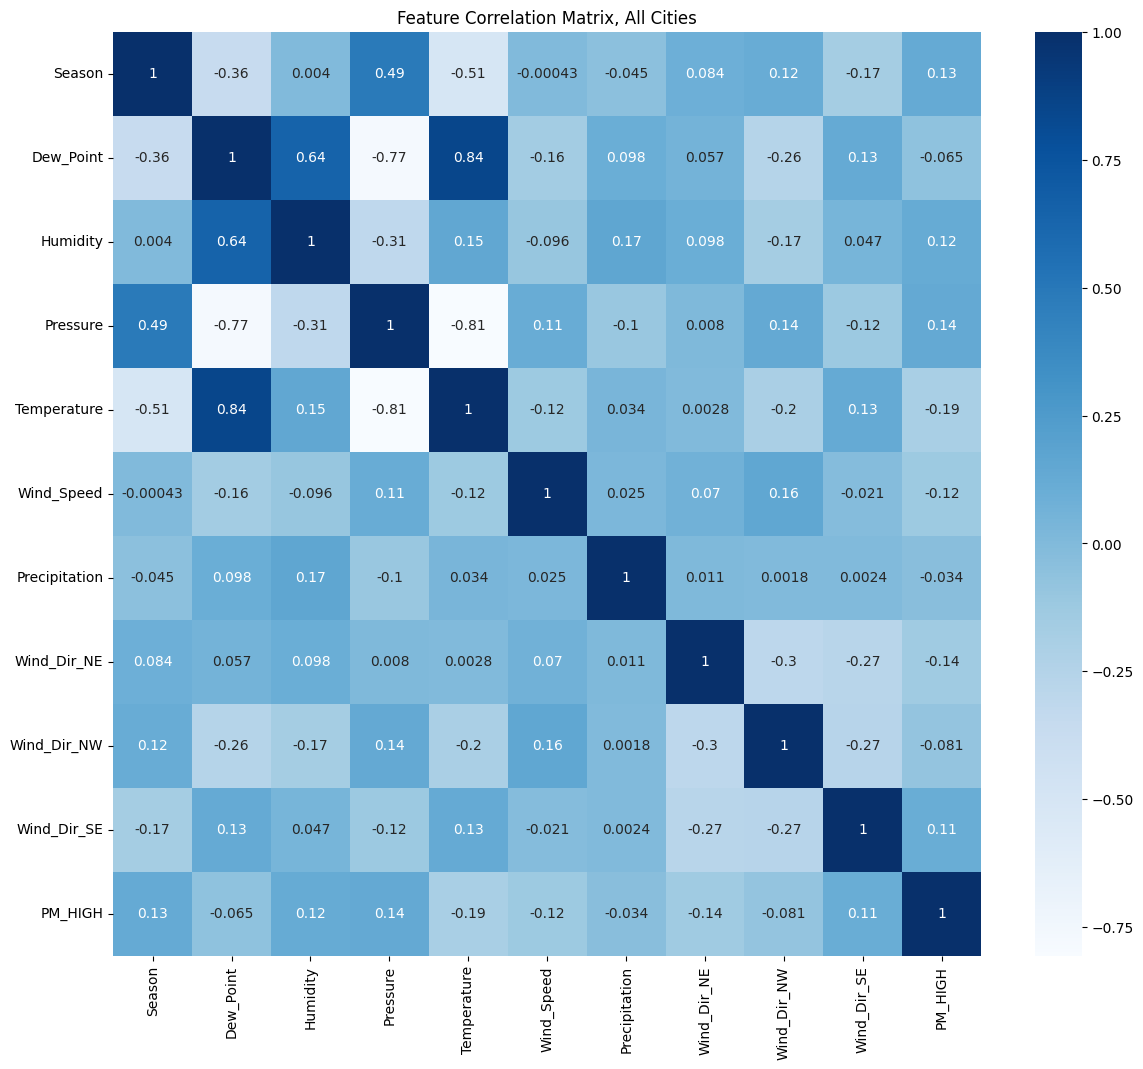

In [11]:
corr_matrix = all_df.corr()
plt.figure(figsize=(14,12))
sns.heatmap(corr_matrix, annot=True, cmap='Blues')
plt.title("Feature Correlation Matrix, All Cities")
plt.show()

### Train Test Split

In [12]:
X = beijing_df.drop(['PM_HIGH', 'City'], axis=1) # I think we need to remove city! For new cities the model will not work... 
y = beijing_df['PM_HIGH']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=21)


### Make Model

Accuracy: 0.7542168674698795


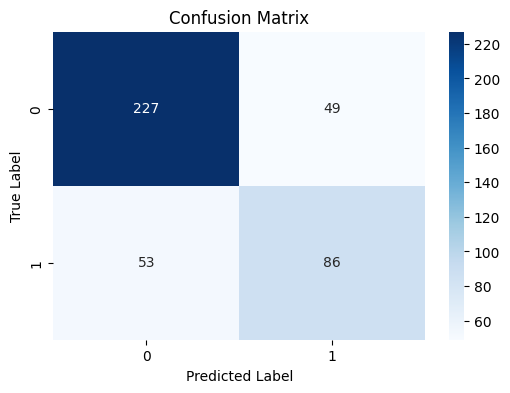

In [16]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

class Classifier():
    def __init__(self, number_of_clusters, max_iterations): # define the attributes here so all the functions can access them
            self.number_of_clusters = number_of_clusters
            self.max_iterations = max_iterations
            self.centroids = None
            self.cluster_labels = {}


    def fit(self, X, y): #   --FRÅN UPPGIFT-- training and storing model parameters that maximize the objective. 
        #  --FRÅN UPPGIFT-- Use K-mean clustering. Train and validate on Beijing and Shenyan.
        #  --FRÅN UPPGIFT-- the classifier should use k-means clustering to identify k cluster centroids 
        self.centroids = (X.sample(n=self.number_of_clusters)).to_numpy() # random centroids
        X = X.to_numpy()

        for _ in range(self.max_iterations):
            distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2) # detta har jag hittat online men jag fattar inte exakt hur alla funktioner fungerar:  https://medium.com/@avijit.bhattacharjee1996/implementing-k-means-clustering-from-scratch-in-python-a277c23563ac
            new_labels = np.argmin(distances, axis=1)
            self.centroids = np.array([X[new_labels == i].mean(axis=0) for i in range(self.number_of_clusters)])

        # --FRÅN UPPGIFT-- each centroid should be assigned a label equal to the majority label of points in the cluster
        distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
        cluster_assignments = np.argmin(distances, axis=1)

        for i in range(self.number_of_clusters):
            self.cluster_labels[i] = y[cluster_assignments == i].mode()[0]
        
    def predict(self, x): # --FRÅN UPPGIFT-- should take a (new) data point x and predict the outcome (e.g., label/cluster)
        x = x.to_numpy()
        dist = self.euclidean(x, self.centroids)
        closest_cluster = np.argmin(dist)
        return self.cluster_labels[closest_cluster]

    def score(self, X, y): # --FRÅN UPPGIFT-- assigns a score to the prediction made for x in comparison to the label y
        true_values = []
        predictions = []
        for i in range(len(X)):
            predictions.append(C.predict(X.iloc[i]))
            true_values.append(y.iloc[i])

        acc = accuracy_score(true_values, predictions)
        print("Accuracy:", acc)
        
        # plot the confusion matrix 
        cm = confusion_matrix(true_values, predictions)    
        plt.figure(figsize=(6,4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.title("Confusion Matrix")
        plt.ylabel("True Label")
        plt.xlabel("Predicted Label")
        plt.show()
        

    def euclidean(self, point, data): # https://towardsdatascience.com/create-your-own-k-means-clustering-algorithm-in-python-d7d4c9077670/
        return np.sqrt(np.sum((point - data)**2, axis=1))

  
C = Classifier(12, 1000)
C.fit(X_train, y_train)
C.score(X_test, y_test)
